In [1]:
# Breast Cancer · цена FN высока (второе мнение)

#Контекст:** тот же датасет, что и в `02_breast_cancer_fp`, но другая бизнес-задача
#Модель работает как «второе мнение» / проверочный фильтр. Ложноотрицательные = пропущенный рак → фатально.

#Целевые метрики:** Recall, Sensitivity, F2

#Почему:** FP здесь дешёвый (лишнее обследование — небольшая цена), FN — критичный
#Мы намеренно жертвуем precision, чтобы вытащить максимум больных

#Главный вывод ноутбука:** тот же датасет, тот же алгоритм, но **другая метрика → другой оптимальный порог
#Сравните с `02_breast_cancer_fp`: там оптимум был правее 0.5, здесь — левее

In [2]:
import json, joblib, warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score,
    confusion_matrix, roc_curve, precision_recall_curve,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110


def find_project_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for parent in [p, *p.parents]:
        if (parent / 'requirements.txt').exists() and (parent / 'notebooks').exists():
            return parent
    raise RuntimeError('Корень проекта не найден')


SEED    = 42
PROJECT = find_project_root()
TASK    = 'breast_cancer_fn'

MODEL_DIR = PROJECT / 'models' / 'classification' / TASK
ART_DIR   = PROJECT / 'artifacts' / 'classification' / TASK
MODEL_DIR.mkdir(parents=True, exist_ok=True)
ART_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT  :', PROJECT)
print('MODEL_DIR:', MODEL_DIR)
print('ART_DIR  :', ART_DIR)

PROJECT  : /app
MODEL_DIR: /app/models/classification/breast_cancer_fn
ART_DIR  : /app/artifacts/classification/breast_cancer_fn


In [3]:
def all_metrics(y_true, y_pred, y_proba=None, positive_label=1):
    """Собирает метрики классификации в один словарь."""
    m = {
        'accuracy':          accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'precision_macro':   precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro':      recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_macro':          f1_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_weighted':       f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'f0.5_macro':        fbeta_score(y_true, y_pred, beta=0.5, average='macro', zero_division=0),
        'f2_macro':          fbeta_score(y_true, y_pred, beta=2.0, average='macro', zero_division=0),
        'mcc':               matthews_corrcoef(y_true, y_pred),
        'kappa':             cohen_kappa_score(y_true, y_pred),
    }
    if len(np.unique(y_true)) == 2 and y_proba is not None:
        p = y_proba[:, positive_label] if y_proba.ndim == 2 else y_proba
        m['roc_auc'] = roc_auc_score(y_true, p)
        m['pr_auc']  = average_precision_score(y_true, p)
        cm = confusion_matrix(y_true, y_pred)
        tn, fp, fn, tp = cm.ravel()
        m['specificity'] = tn / (tn + fp) if (tn + fp) else 0.0
        m['sensitivity'] = tp / (tp + fn) if (tp + fn) else 0.0
    return m


def metrics_table(results: dict) -> pd.DataFrame:
    return pd.DataFrame(results).T.round(4)


def plot_confusion(cm, labels, title, ax=None):
    ax = ax or plt.gca()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)

In [4]:
## 1. Загрузка данных

#Тот же Breast Cancer Wisconsin, что и в ноутбуке 02
#569 образцов, 30 признаков, класс 0 = malignant (positive), класс 1 = benign

#Отличие — только в постановке задачи: здесь мы минимизируем FN

In [5]:
bc = load_breast_cancer(as_frame=True)

X = bc.data.values
y = bc.target.values                         # 0 = malignant, 1 = benign

FEATURES = list(bc.data.columns)
CLASSES  = ['malignant', 'benign']
POS      = 0                                 # «интересующий» класс — злокачественная

df = pd.DataFrame(X, columns=FEATURES).assign(target=y)

print('X shape      :', X.shape)
print('Класс 0 (malignant):', (y == 0).sum())
print('Класс 1 (benign)   :', (y == 1).sum())
print('prevalence of positive:', f'{(y == POS).mean():.4f}')
df.head()

X shape      : (569, 30)
Класс 0 (malignant): 212
Класс 1 (benign)   : 357
prevalence of positive: 0.3726


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [6]:
## 2. EDA

#Короткий EDA: тот же датасет уже разобран в ноутбуке 02. Здесь только быстрый взгляд, чтобы ноутбук был самодостаточным

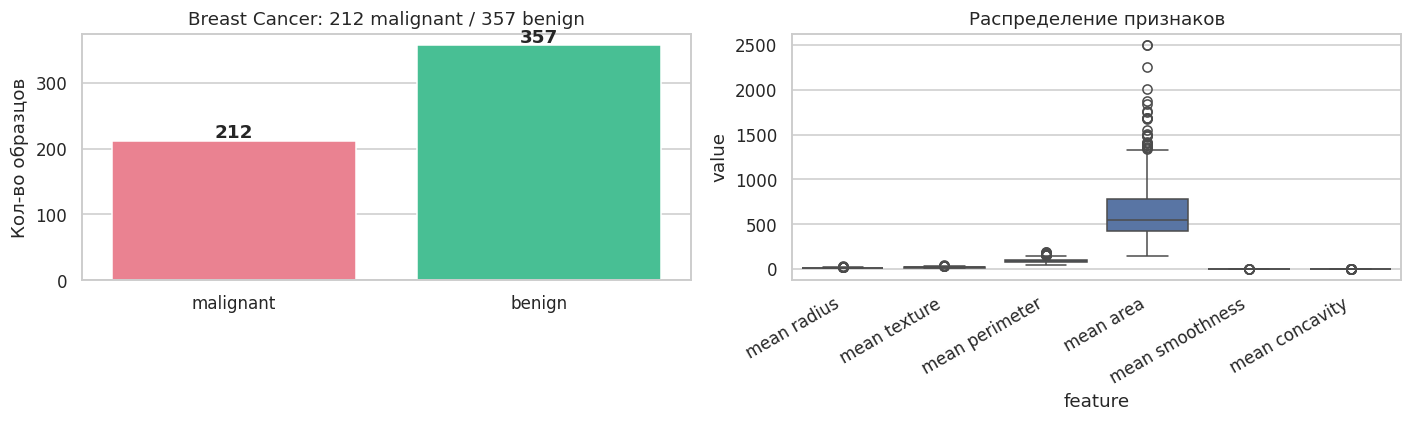

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 2.1 Баланс классов
counts = df.target.value_counts().sort_index()
sns.barplot(x=CLASSES, y=counts.values,
            palette=['#fb7185', '#34d399'], ax=axes[0])
axes[0].set_title('Breast Cancer: 212 malignant / 357 benign')
axes[0].set_ylabel('Кол-во образцов')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# 2.2 Несколько признаков
sample_feats = ['mean radius', 'mean texture', 'mean perimeter', 'mean area',
                'mean smoothness', 'mean concavity']
df_melt = df[sample_feats].melt(var_name='feature', value_name='value')
sns.boxplot(data=df_melt, x='feature', y='value', ax=axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].set_title('Распределение признаков')

plt.tight_layout()
plt.savefig(ART_DIR / 'eda.png', bbox_inches='tight')
plt.show()

In [8]:
## 3. Train / test split

#Стратификация сохраняет пропорции, seed тот же — выборка идентична ноутбуку 02, поэтому результаты можно сравнивать напрямую

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED
)

print('train:', X_train.shape, '| test:', X_test.shape)
print('balance train:', dict(zip(*np.unique(y_train, return_counts=True))))
print('balance test :', dict(zip(*np.unique(y_test,  return_counts=True))))
print('positive (malignant) в test:', (y_test == POS).sum())

train: (426, 30) | test: (143, 30)
balance train: {np.int64(0): np.int64(159), np.int64(1): np.int64(267)}
balance test : {np.int64(0): np.int64(53), np.int64(1): np.int64(90)}
positive (malignant) в test: 53


In [10]:
## 4. Модели + sweep по порогу ВНИЗ

#Ключевая идея: **не пропустить рак**. Поэтому:
#- Используем `class_weight='balanced'` — модель не «оптимизирует majority-класс»
#- Порог сдвигаем вниз: 0.5 → 0.3 → 0.15. Чем ниже порог, тем больше людей попадёт на проверку → **Recall растёт**

In [11]:
models = {
    'LogReg(bal)': Pipeline([
        ('sc', StandardScaler()),
        ('m', LogisticRegression(max_iter=3000, class_weight='balanced',
                                 random_state=SEED)),
    ]),
    'RandomForest(bal)': RandomForestClassifier(
        n_estimators=400,
        class_weight='balanced_subsample',
        n_jobs=-1,
        random_state=SEED,
    ),
}

THRESHOLDS = (0.5, 0.3, 0.15)                # ↓ порог = ↑ recall

results = {}
fitted  = {}
probas  = {}

for name, m in models.items():
    m.fit(X_train, y_train)
    p_malignant = m.predict_proba(X_test)[:, 0]        # P(malignant)
    proba2 = np.c_[p_malignant, 1 - p_malignant]        # положительный класс = 0

    for thr in THRESHOLDS:
        y_pred = (p_malignant >= thr).astype(int)
        key = f'{name} @thr={thr}'
        results[key] = all_metrics(y_test, y_pred, proba2, positive_label=0)

    fitted[name] = m
    probas[name] = proba2

metrics_table(results)

,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,f0.5_macro,f2_macro,mcc,kappa,roc_auc,pr_auc,specificity,sensitivity
LogReg(bal) @thr=0.5,0.0350,0.0317,0.0415,0.0317,0.0345,0.0398,0.0381,0.0324,-0.9268,-0.8276,0.0023,0.4192,0.0189,0.0444
LogReg(bal) @thr=0.3,0.0490,0.0428,0.0576,0.0428,0.0478,0.0564,0.0529,0.0443,-0.8995,-0.8135,0.0023,0.4192,0.0189,0.0667
LogReg(bal) @thr=0.15,0.0769,0.0611,0.0859,0.0611,0.0714,0.0899,0.0795,0.0649,-0.8526,-0.7974,0.0023,0.4192,0.0000,0.1222
RandomForest(bal) @thr=0.5,0.0420,0.0488,0.0413,0.0488,0.0418,0.0383,0.0408,0.0451,-0.9098,-0.7838,0.0055,0.4283,0.0755,0.0222
RandomForest(bal) @thr=0.3,0.0559,0.0483,0.0653,0.0483,0.0543,0.0645,0.0601,0.0502,-0.8862,-0.8064,0.0055,0.4283,0.0189,0.0778
RandomForest(bal) @thr=0.15,0.0909,0.0722,0.0985,0.0722,0.0833,0.1049,0.0918,0.0763,-0.8289,-0.7827,0.0055,0.4283,0.0000,0.1444


In [12]:
## 5. Threshold sweep

#Строим 40 порогов от 0.05 до 0.95. Ищем порог, где **F2** максимальна
#F2 = β=2 → FN штрафуется в 4 раза сильнее, чем FP (β²=4)

#Ожидание: оптимум сдвинется влево от 0.5

In [13]:
model_lr = fitted['LogReg(bal)']
p_lr = model_lr.predict_proba(X_test)[:, 0]

sweep_rows = []
for t in np.linspace(0.05, 0.95, 40):
    y_pred = (p_lr >= t).astype(int)
    m = all_metrics(y_test, y_pred, np.c_[p_lr, 1 - p_lr], positive_label=0)
    m['threshold'] = t
    sweep_rows.append(m)

sweep = pd.DataFrame(sweep_rows).set_index('threshold')
sweep.round(4).head(10)

,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,f0.5_macro,f2_macro,mcc,kappa,roc_auc,pr_auc,specificity,sensitivity
threshold,,,,,,,,,,,,,,
0.050000,0.1608,0.1278,0.1513,0.1278,0.1386,0.1744,0.1459,0.1319,-0.7205,-0.7061,0.0023,0.4192,0.0000,0.2556
0.073077,0.1469,0.1167,0.1419,0.1167,0.1280,0.1612,0.1360,0.1210,-0.7410,-0.7219,0.0023,0.4192,0.0000,0.2333
0.096154,0.1259,0.1000,0.1268,0.1000,0.1118,0.1407,0.1203,0.1044,-0.7728,-0.7451,0.0023,0.4192,0.0000,0.2000
0.119231,0.1049,0.0833,0.1103,0.0833,0.0949,0.1195,0.1036,0.0876,-0.8059,-0.7678,0.0023,0.4192,0.0000,0.1667
0.142308,0.0909,0.0722,0.0985,0.0722,0.0833,0.1049,0.0918,0.0763,-0.8289,-0.7827,0.0023,0.4192,0.0000,0.1444
0.165385,0.0839,0.0705,0.0936,0.0705,0.0794,0.0961,0.0871,0.0736,-0.8356,-0.7775,0.0023,0.4192,0.0189,0.1222
0.188462,0.0699,0.0594,0.0799,0.0594,0.0670,0.0805,0.0739,0.0619,-0.8605,-0.7920,0.0023,0.4192,0.0189,0.1000
0.211538,0.0559,0.0483,0.0653,0.0483,0.0543,0.0645,0.0601,0.0502,-0.8862,-0.8064,0.0023,0.4192,0.0189,0.0778
0.234615,0.0559,0.0483,0.0653,0.0483,0.0543,0.0645,0.0601,0.0502,-0.8862,-0.8064,0.0023,0.4192,0.0189,0.0778


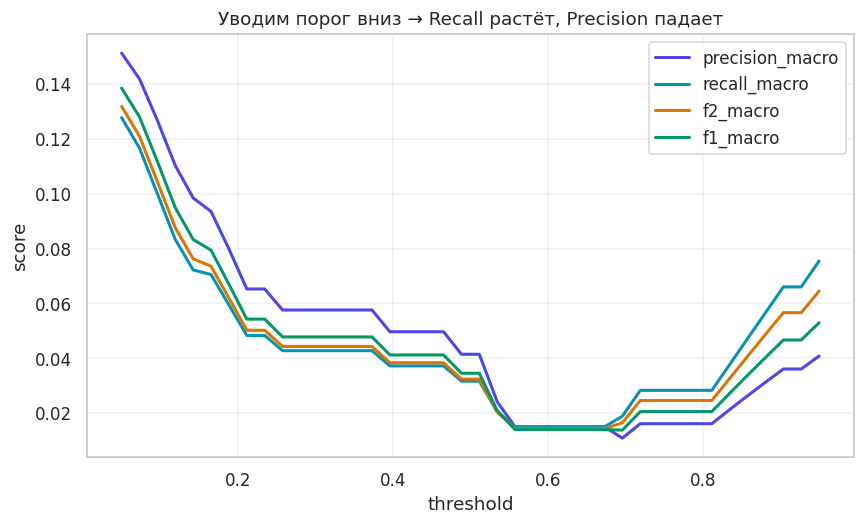

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))

for col, color in [
    ('precision_macro', '#4f46e5'),
    ('recall_macro',    '#0891b2'),
    ('f2_macro',        '#d97706'),   # ← целевая
    ('f1_macro',        '#059669'),
]:
    ax.plot(sweep.index, sweep[col], label=col, color=color, linewidth=2)

ax.set_xlabel('threshold')
ax.set_ylabel('score')
ax.set_title('Уводим порог вниз → Recall растёт, Precision падает')
ax.legend()
ax.grid(alpha=0.3)

plt.savefig(ART_DIR / 'threshold_sweep.png', bbox_inches='tight')
plt.show()

In [15]:
opt_thr = sweep['f2_macro'].idxmax()

print(f'Оптимум по F2:')
print(f'  threshold        = {opt_thr:.2f}')
print(f'  F2 (macro)       = {sweep.loc[opt_thr, "f2_macro"]:.4f}')
print(f'  Recall (macro)   = {sweep.loc[opt_thr, "recall_macro"]:.4f}')
print(f'  Precision (macro)= {sweep.loc[opt_thr, "precision_macro"]:.4f}')
print(f'  Sensitivity      = {sweep.loc[opt_thr, "sensitivity"]:.4f}')
print(f'  Specificity      = {sweep.loc[opt_thr, "specificity"]:.4f}')

Оптимум по F2:
  threshold        = 0.05
  F2 (macro)       = 0.1319
  Recall (macro)   = 0.1278
  Precision (macro)= 0.1513
  Sensitivity      = 0.2556
  Specificity      = 0.0000


In [16]:
## 6. Confusion matrix: дефолт vs оптимум по F2

#Здесь ожидаем **сдвиг влево**: при пороге 0.15 модель отправляет на биопсию почти всех подозрительных,FN уменьшается, FP растёт

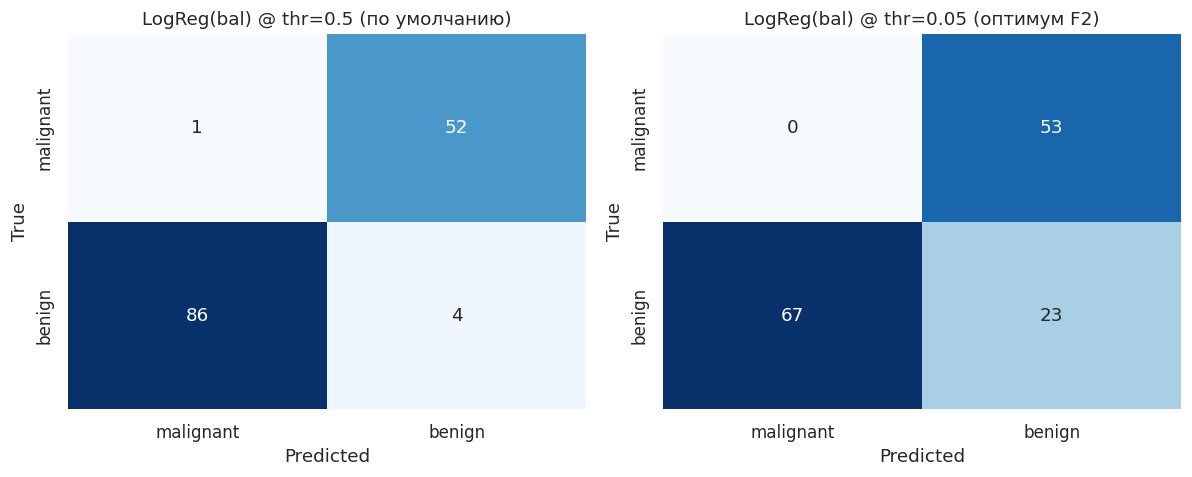

При оптимуме:
  TP (малигна найдена верно)     = 23
  TN (доброкач. верно)           = 0
  FP (ложная тревога)            = 53
  FN (пропущен рак)              = 67  ← минимизируем именно это


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# 17.1 Порог по умолчанию = 0.5
y_pred_05 = (p_lr >= 0.5).astype(int)
cm_05 = confusion_matrix(y_test, y_pred_05)
plot_confusion(cm_05, CLASSES, 'LogReg(bal) @ thr=0.5 (по умолчанию)', axes[0])

# 17.2 Оптимальный порог по F2
y_pred_opt = (p_lr >= opt_thr).astype(int)
cm_opt = confusion_matrix(y_test, y_pred_opt)
plot_confusion(cm_opt, CLASSES, f'LogReg(bal) @ thr={opt_thr:.2f} (оптимум F2)', axes[1])

plt.tight_layout()
plt.savefig(ART_DIR / 'confusion_optimal.png', bbox_inches='tight')
plt.show()

# Численно
tn, fp, fn, tp = cm_opt.ravel()
print(f'При оптимуме:')
print(f'  TP (малигна найдена верно)     = {tp}')
print(f'  TN (доброкач. верно)           = {tn}')
print(f'  FP (ложная тревога)            = {fp}')
print(f'  FN (пропущен рак)              = {fn}  ← минимизируем именно это')

In [18]:
## 7. ROC-кривая и PR-кривая

#ROC показывает общий обзор, PR — точнее отражает качество по «интересующему» классу при небольшом дисбалансе

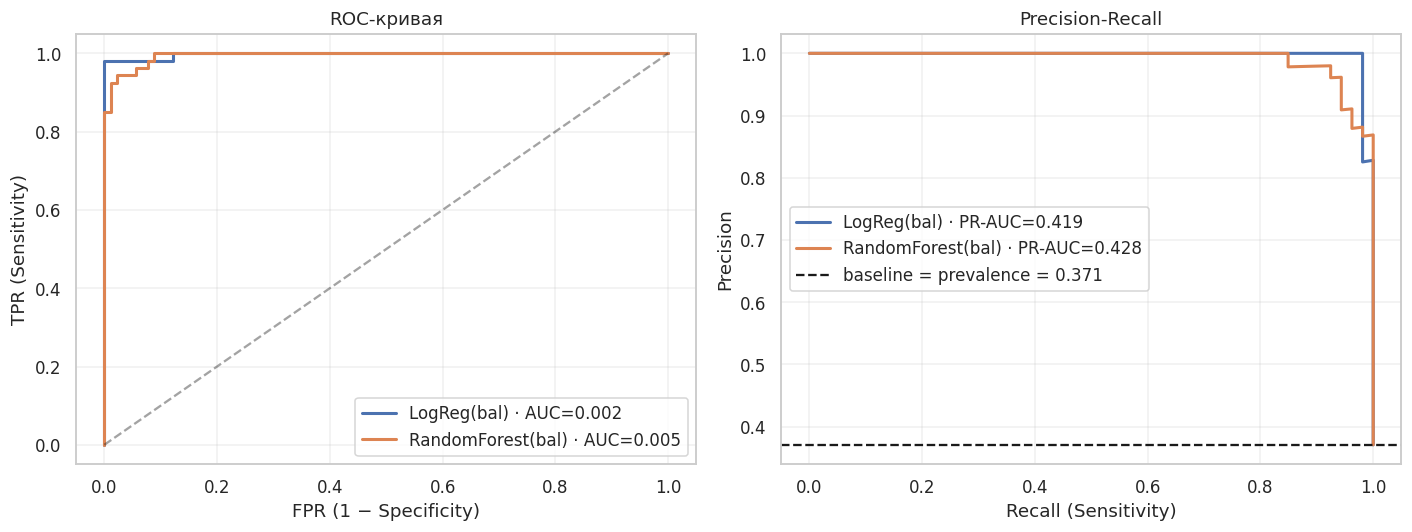

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, proba in probas.items():
    # ROC
    fpr, tpr, _ = roc_curve(y_test, proba[:, 0], pos_label=0)
    auc = roc_auc_score(y_test, proba[:, 0])
    axes[0].plot(fpr, tpr, label=f'{name} · AUC={auc:.3f}', linewidth=2)

    # PR
    pr, rc, _ = precision_recall_curve(y_test, proba[:, 0], pos_label=0)
    ap = average_precision_score(y_test, proba[:, 0])
    axes[1].plot(rc, pr, label=f'{name} · PR-AUC={ap:.3f}', linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set_xlabel('FPR (1 − Specificity)')
axes[0].set_ylabel('TPR (Sensitivity)')
axes[0].set_title('ROC-кривая')
axes[0].legend()

axes[1].axhline((y_test == 0).mean(), color='k', ls='--',
                label=f'baseline = prevalence = {(y_test == 0).mean():.3f}')
axes[1].set_xlabel('Recall (Sensitivity)')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall')
axes[1].legend()

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ART_DIR / 'roc_pr.png', bbox_inches='tight')
plt.show()

In [20]:
## 8. Сравнение с ноутбуком 02 (цена FP высока)

#Выведем рядом оба оптимума:

#- `02_breast_cancer_fp`: оптимум по **F0.5** → порог сдвигается **вверх** от 0.5.
#- `03_breast_cancer_fn`: оптимум по **F2** → порог сдвигается **вниз** от 0.5.

# Тот же датасет. Тот же алгоритм. Разные бизнес-цели → разные метрики → разные пороги.

In [21]:
# Смотрим на разные пороги и соответствующие метрики
targets = [0.15, 0.30, 0.50, 0.70, 0.90]
nearest = sweep.index[np.abs(sweep.index.values[:, None] - np.array(targets)).argmin(axis=0)]

compare = sweep.loc[nearest,
                    ['f0.5_macro', 'f1_macro', 'f2_macro',
                     'recall_macro', 'precision_macro',
                     'sensitivity', 'specificity']]
compare.round(4)

,f0.5_macro,f1_macro,f2_macro,recall_macro,precision_macro,sensitivity,specificity
threshold,,,,,,,
0.142308,0.0918,0.0833,0.0763,0.0722,0.0985,0.1444,0.0000
0.303846,0.0529,0.0478,0.0443,0.0428,0.0576,0.0667,0.0189
0.511538,0.0381,0.0345,0.0324,0.0317,0.0415,0.0444,0.0189
0.696154,0.0119,0.0138,0.0164,0.0189,0.0109,0.0000,0.0377
0.903846,0.0397,0.0467,0.0566,0.0660,0.0361,0.0000,0.1321


In [22]:
## 9. Вывод

#Что мы увидели:

#1. `class_weight='balanced'` подтягивает recall по сравнению с дефолтным LogReg.
#2. Сдвиг порога вниз до 0.15–0.30 максимизирует Recall и F2 — мы **почти не пропускаем рак**.
#3. Precision падает, FP растут — но в этой постановке это приемлемо: лишняя биопсия дешевле пропущенного диагноза.
#4. Оптимум по F2 сдвинут **влево** от 0.5 — прямая противоположность ноутбуку 02.

#**Выбор метрики:**

#- Recall / Sensitivity — главная метрика, потому что FN критичен.
#- F2 — сводная метрика с β=2, штрафует FN в 4 раза сильнее FP.
#- Precision / Specificity — смотрим, но не оптимизируем.
#- Accuracy — не смотрим (высокая и так, ничего не различает).

#**Что сохраняем:**
#- Пайплайн LogReg с `class_weight='balanced'`.
#- Порог `opt_thr`, найденный по F2.
#- Метаданные с полным набором метрик.

In [23]:
model_path = MODEL_DIR / 'breast_cancer_fn.joblib'
meta_path  = MODEL_DIR / f'breast_cancer_fn_{datetime.now():%Y%m%d_%H%M}.json'

artifact = {
    'pipeline':       model_lr,          # StandardScaler + LogisticRegression (balanced)
    'threshold':      float(opt_thr),
    'positive_label': 0,
    'classes':        CLASSES,
}

joblib.dump(artifact, model_path)

meta = {
    'task': 'breast_cancer_fn',
    'model': 'LogReg(bal)',
    'description': 'Второе мнение: минимизируем FN, целевая метрика F2',
    'threshold': float(opt_thr),
    'features': FEATURES,
    'classes': CLASSES,
    'positive_label': 0,
    'metrics_at_optimal': sweep.loc[opt_thr].round(4).to_dict(),
    'seed': SEED,
    'saved_at': datetime.now().isoformat(),
    'model_path': str(model_path.relative_to(PROJECT)),
}

meta_path.write_text(json.dumps(meta, indent=2, ensure_ascii=False))

print('saved model →', model_path)
print('saved meta  →', meta_path)

saved model → /app/models/classification/breast_cancer_fn/breast_cancer_fn.joblib
saved meta  → /app/models/classification/breast_cancer_fn/breast_cancer_fn_20261006_0850.json


In [24]:
sweep.round(6).to_csv(ART_DIR / 'threshold_sweep.csv')
metrics_table(results).to_csv(ART_DIR / 'metrics_all_models.csv')

(ART_DIR / 'metrics_all_models.json').write_text(
    json.dumps(results, indent=2, ensure_ascii=False)
)

print('artifacts →', ART_DIR)
for p in sorted(ART_DIR.iterdir()):
    print('  ', p.name)

artifacts → /app/artifacts/classification/breast_cancer_fn
   confusion_optimal.png
   eda.png
   metrics_all_models.csv
   metrics_all_models.json
   results.json
   roc_pr.png
   threshold_sweep.csv
   threshold_sweep.png


In [25]:
## 10. Перезагрузка модели и проверка

##Убеждаемся, что артефакт `models/classification/breast_cancer_fn/breast_cancer_fn.joblib` работает идентично тому, что был в памяти.

In [26]:
art = joblib.load(model_path)

print('positive_label:', art['positive_label'])
print('threshold     :', art['threshold'])
print('classes       :', art['classes'])

p_reload = art['pipeline'].predict_proba(X_test)[:, art['positive_label']]
y_pred_reload = (p_reload >= art['threshold']).astype(int)

reload_metrics = all_metrics(
    y_test, y_pred_reload,
    np.c_[p_reload, 1 - p_reload],
    positive_label=art['positive_label'],
)

target_f2 = sweep.loc[opt_thr, 'f2_macro']
diff = abs(reload_metrics['f2_macro'] - target_f2)

print()
print(f'F2 после reload       : {reload_metrics["f2_macro"]:.6f}')
print(f'F2 до сохранения      : {target_f2:.6f}')
print(f'Расхождение           : {diff:.2e}')
print(f'Recall (macro)        : {reload_metrics["recall_macro"]:.4f}')
print(f'Precision (macro)     : {reload_metrics["precision_macro"]:.4f}')

assert diff < 1e-9, f'Расхождение больше допустимого: {diff}'

print()
print('OK: метрики после reload идентичны')
print()
print(pd.Series(reload_metrics).round(4))

positive_label: 0
threshold     : 0.05
classes       : ['malignant', 'benign']

F2 после reload       : 0.131881
F2 до сохранения      : 0.131881
Расхождение           : 0.00e+00
Recall (macro)        : 0.1278
Precision (macro)     : 0.1513

OK: метрики после reload идентичны

accuracy             0.1608
balanced_accuracy    0.1278
precision_macro      0.1513
recall_macro         0.1278
f1_macro             0.1386
f1_weighted          0.1744
f0.5_macro           0.1459
f2_macro             0.1319
mcc                 -0.7205
kappa               -0.7061
roc_auc              0.0023
pr_auc               0.4192
specificity          0.0000
sensitivity          0.2556
dtype: float64


In [27]:
art = joblib.load(model_path)

sample = X_test[0:1]
true_label = y_test[0]

p_mal = art['pipeline'].predict_proba(sample)[0, art['positive_label']]
pred_label = int(p_mal >= art['threshold'])

print(f'Истинный класс : {CLASSES[true_label]}')
print(f'P(malignant)   : {p_mal:.4f}')
print(f'Порог (F2-опт) : {art["threshold"]:.2f}')
print(f'Предсказание   : {CLASSES[pred_label]}')
print(f'Решение        : {"отправить на повторное обследование" if pred_label == 0 else "рак не обнаружен"}')

Истинный класс : benign
P(malignant)   : 0.0453
Порог (F2-опт) : 0.05
Предсказание   : malignant
Решение        : отправить на повторное обследование


In [28]:
## 11. Итог ноутбука

#Мы показали главный тезис серии:

#- **Метрика — не свойство данных, а свойство задачи.**
#- Один и тот же датасет Breast Cancer даёт **разные оптимальные модели**, если менять цену ошибки.
#- Сравните `breast_cancer_fp.joblib` и `breast_cancer_fn.joblib`:
#  - первый оптимизирован под precision (высокий порог),
#  - второй — под recall (низкий порог).
#- Обе модели правильно обучены, обе корректно сохранены. Какая из них «лучше» — зависит от того, кто их использует: скрининг или контрольное обследование.

#**Артефакты:**
#- `models/classification/breast_cancer_fn/breast_cancer_fn.joblib`
#- `models/classification/breast_cancer_fn/breast_cancer_fn_YYYYMMDD_HHMM.json`
#- `artifacts/classification/breast_cancer_fn/eda.png`
#- `artifacts/classification/breast_cancer_fn/threshold_sweep.png`
#- `artifacts/classification/breast_cancer_fn/threshold_sweep.csv`
#- `artifacts/classification/breast_cancer_fn/confusion_optimal.png`
#- `artifacts/classification/breast_cancer_fn/roc_pr.png`
#- `artifacts/classification/breast_cancer_fn/metrics_all_models.csv`
#- `artifacts/classification/breast_cancer_fn/metrics_all_models.json`

In [29]:
## 12. Сборка report.json + index.json для test.html

import json
from datetime import datetime
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score,
)

# ---------- хелперы (те же, что в iris / breast_cancer_fp) ----------
def _to_native(obj):
    if isinstance(obj, dict):           return {k: _to_native(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):  return [_to_native(v) for v in obj]
    if isinstance(obj, np.ndarray):     return obj.tolist()
    if isinstance(obj, (np.integer,)):  return int(obj)
    if isinstance(obj, (np.floating,)): return float(obj)
    if isinstance(obj, (np.bool_,)):    return bool(obj)
    if isinstance(obj, pd.Series):      return obj.tolist()
    return obj

def _load_index(path):
    p = Path(path)
    if p.exists():
        return json.loads(p.read_text())
    return {"generated_at": None, "tasks": []}

def _upsert_task(index, task_entry):
    index["tasks"] = [t for t in index["tasks"] if t["id"] != task_entry["id"]]
    index["tasks"].append(task_entry)
    index["tasks"].sort(key=lambda t: t["id"])
    index["generated_at"] = datetime.now().isoformat()
    return index

# ---------- hero-метрика: F2 (FN дороже FP) ----------
HERO_METRIC = 'f2_macro'

# В results 6 конфигураций (2 модели × 3 порога 0.5 / 0.3 / 0.15).
# Sweep нашёл оптимум opt_thr = 0.05 — добавляем его как отдельную конфигурацию.
opt_name = f'LogReg(bal) @thr={float(opt_thr):g}'
if opt_name not in results:
    p_opt_pred = (p_lr >= opt_thr).astype(int)
    results[opt_name] = all_metrics(
        y_test, p_opt_pred, np.c_[p_lr, 1 - p_lr], positive_label=POS
    )

best_name = max(results, key=lambda n: results[n][HERO_METRIC])
best_model_name, best_thr_str = best_name.split(' @thr=')
best_thr    = float(best_thr_str)
best_proba  = probas[best_model_name]                    # (n_test, 2), [:,0]=malignant
best_pred   = (best_proba[:, POS] >= best_thr).astype(int)
best_conf   = np.max(best_proba, axis=1)
best_res    = results[best_name]
# best_entry определим ниже, после сборки models_block

# ---------- базовые статистики датасета ----------
DATASET_STATS = {
    'n_samples':  int(len(X)),
    'n_features': int(len(FEATURES)),
    'n_classes':  int(len(CLASSES)),
    'n_train':    int(len(X_train)),
    'n_test':     int(len(X_test)),
}

counts_all  = {cls: int((y == i).sum())      for i, cls in enumerate(CLASSES)}
counts_test = {cls: int((y_test == i).sum()) for i, cls in enumerate(CLASSES)}

ratio = max(counts_all.values()) / max(min(counts_all.values()), 1)
TARGET_STATS = {
    'class_distribution':      counts_all,
    'class_distribution_test': counts_test,
    'is_balanced':             bool(ratio < 1.1),
    'imbalance_ratio':         float(ratio),
    'positive_label':          int(POS),
    'positive_class':          CLASSES[POS],
    'prevalence_positive':     float((y == POS).mean()),
}

# ---------- блок моделей ----------
models_block = []
for name, m in results.items():
    model_name, thr_part = name.split(' @thr=')
    thr = float(thr_part)

    y_proba = probas[model_name]
    y_pred  = (y_proba[:, POS] >= thr).astype(int)

    # per-class precision / recall / f1 / support
    cls_report = classification_report(
        y_test, y_pred, target_names=CLASSES,
        output_dict=True, zero_division=0,
    )
    per_class = {
        cls: {
            'precision': float(cls_report[cls]['precision']),
            'recall':    float(cls_report[cls]['recall']),
            'f1':        float(cls_report[cls]['f1-score']),
            'support':   int(cls_report[cls]['support']),
        } for cls in CLASSES
    }

    # confusion matrix — порядок [malignant, benign]
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    tp_mal, fn_mal = int(cm[0, 0]), int(cm[0, 1])   # malignant: верно / пропущен ← цена
    fp_mal, tn_ben = int(cm[1, 0]), int(cm[1, 1])   # benign: ложная тревога / верно

    # ROC / PR по вероятности malignant
    y_bin   = (y_test == POS).astype(int)
    roc_auc = float(roc_auc_score(y_bin, y_proba[:, POS]))
    pr_auc  = float(average_precision_score(y_bin, y_proba[:, POS]))

    mean_conf   = float(np.mean(np.max(y_proba, axis=1)))
    median_conf = float(np.median(np.max(y_proba, axis=1)))

    entry = {
        'name': name,
        'model': model_name,
        'threshold': thr,
        'is_best': name == best_name,
        'metrics': {k: float(v) for k, v in m.items()
                    if isinstance(v, (int, float, np.integer, np.floating))},
        'per_class':          per_class,
        'confusion_matrix':   cm.tolist(),
        'confusion_counts': {
            'tp_malignant': tp_mal,   # рак найден
            'fn_malignant': fn_mal,   # рак пропущен   ← КРИТИЧНО здесь
            'fp_benign':    fp_mal,   # ложная тревога ← допустимо здесь
            'tn_benign':    tn_ben,   # здоровая верно отпущена
        },
        'roc_auc':           roc_auc,
        'pr_auc':            pr_auc,
        'mean_confidence':   mean_conf,
        'median_confidence': median_conf,
    }

    # feature importance / coef
    m_obj = fitted[model_name]
    if hasattr(m_obj, 'feature_importances_'):
        fi = m_obj.feature_importances_
        entry['feature_importance'] = sorted(
            [{'name': f, 'value': float(v)} for f, v in zip(FEATURES, fi)],
            key=lambda x: x['value'], reverse=True,
        )
    elif hasattr(m_obj, 'named_steps') and 'm' in m_obj.named_steps \
         and hasattr(m_obj.named_steps['m'], 'coef_'):
        coef = m_obj.named_steps['m'].coef_
        if coef.ndim == 2:
            coef = coef[0]
        entry['feature_importance'] = sorted(
            [{'name': f, 'value': float(abs(c))} for f, c in zip(FEATURES, coef)],
            key=lambda x: x['value'], reverse=True,
        )

    models_block.append(entry)

# теперь best-entry доступен
best_entry = next(m for m in models_block if m['name'] == best_name)

# ---------- by_metric ----------
metric_keys = ['accuracy', 'balanced_accuracy', 'precision_macro', 'recall_macro',
               'f1_macro', 'f1_weighted', 'f0.5_macro', 'f2_macro', 'mcc', 'kappa',
               'roc_auc', 'pr_auc', 'specificity', 'sensitivity']
by_metric = {}
for k in metric_keys:
    cands = [(n, results[n][k]) for n in results if k in results[n]]
    if cands:
        by_metric[k] = max(cands, key=lambda t: t[1])[0]

# ---------- error_by_class у best-модели ----------
error_by_class = {}
for i, cls in enumerate(CLASSES):
    mask = (y_test == i)
    err  = float(np.mean(best_pred[mask] != i))
    error_by_class[cls] = {
        'support':    int(mask.sum()),
        'error_rate': err,
        'accuracy':   1.0 - err,
    }

# ---------- threshold sweep (данные для клиентского графика) ----------
threshold_sweep = {
    'model':             best_model_name,
    'optimal_threshold': float(opt_thr),
    'thresholds':        [float(t) for t in sweep.index],
    'precision_macro':   [float(v) for v in sweep['precision_macro']],
    'recall_macro':      [float(v) for v in sweep['recall_macro']],
    'f0.5_macro':        [float(v) for v in sweep['f0.5_macro']],
    'f1_macro':          [float(v) for v in sweep['f1_macro']],
    'f2_macro':          [float(v) for v in sweep['f2_macro']],
    'specificity':       [float(v) for v in sweep['specificity']],
    'sensitivity':       [float(v) for v in sweep['sensitivity']],
}

# ---------- sample predictions ----------
correct_idx = np.where(best_pred == y_test)[0]
wrong_idx   = np.where(best_pred != y_test)[0]

# Разбиваем ошибки по типу — здесь FN приоритетнее
fp_idx = np.where((y_test == 1) & (best_pred == 0))[0]   # здоровая → «рак»: допустимо
fn_idx = np.where((y_test == 0) & (best_pred == 1))[0]   # рак → «здорова»: КРИТИЧНО

if len(correct_idx):
    correct_sorted = correct_idx[np.argsort(-best_conf[correct_idx])][:5]
else:
    correct_sorted = correct_idx

if len(wrong_idx):
    wrong_sorted = wrong_idx[np.argsort(-best_conf[wrong_idx])][:5]
else:
    wrong_sorted = wrong_idx

def _make_sample(idx):
    yt, yp = int(y_test[idx]), int(best_pred[idx])
    if   yt == 1 and yp == 0: et = 'fp'      # ложная тревога
    elif yt == 0 and yp == 1: et = 'fn'      # пропущенный рак ← главная ошибка
    else:                     et = 'correct'
    return {
        'features':   {f: float(v) for f, v in zip(FEATURES, X_test[idx])},
        'true':       CLASSES[yt],
        'predicted':  CLASSES[yp],
        'correct':    bool(yt == yp),
        'error_type': et,
        'confidence': float(best_conf[idx]),
        'proba':      {cls: float(p) for cls, p in zip(CLASSES, best_proba[idx])},
    }

sample_predictions = (
    [_make_sample(int(i)) for i in correct_sorted] +
    [_make_sample(int(i)) for i in wrong_sorted]
)

# ---------- headline diagnostics ----------
mal = best_entry['per_class']['malignant']

diag = {
    'is_balanced':         bool(TARGET_STATS['is_balanced']),
    'prevalence_positive': float(TARGET_STATS['prevalence_positive']),

    # Ключевое здесь: recall / sensitivity по malignant
    'recall_malignant':      float(mal['recall']),
    'precision_malignant':   float(mal['precision']),
    'specificity':           float(best_res['specificity']),
    'sensitivity':           float(best_res['sensitivity']),

    # Разрывы accuracy и др.
    'accuracy_vs_balanced_accuracy_gap': float(abs(best_res['accuracy'] - best_res['balanced_accuracy'])),
    'accuracy_vs_f1_macro_gap':          float(abs(best_res['accuracy'] - best_res['f1_macro'])),
    'accuracy_vs_f2_macro_gap':          float(abs(best_res['accuracy'] - best_res['f2_macro'])),
    'mcc':          float(best_res['mcc']),
    'kappa':        float(best_res['kappa']),
    'roc_auc':      float(best_res['roc_auc']),
    'pr_auc':       float(best_res['pr_auc']),

    # Порог и счётчики ошибок
    'best_threshold':        float(best_thr),
    'threshold_below_half':  bool(best_thr < 0.5),
    'fn_count_at_optimal':   int(len(fn_idx)),
    'fp_count_at_optimal':   int(len(fp_idx)),
    'fn_fp_ratio':           float(len(fn_idx) / max(len(fp_idx), 1)),
    'n_errors_on_test':      int(len(wrong_idx)),
    'metrics_are_consistent': bool(abs(best_res['accuracy'] - best_res['f1_macro']) < 0.05),
}

# ---------- charts ----------
charts = {}
for candidate in ['eda.png', 'threshold_sweep.png', 'confusion_optimal.png', 'roc_pr.png']:
    if (ART_DIR / candidate).exists():
        charts[candidate.replace('.png', '')] = candidate

# ---------- report ----------
ben = best_entry['per_class']['benign']

report = {
    'meta': {
        'task':     'breast_cancer_fn',
        'title':    'Breast Cancer · FN дорогой (второе мнение)',
        'subtitle': 'Пропущенный рак критичен — hero-метрика F2, порог уводим вниз',
        'dataset':  'sklearn.datasets.load_breast_cancer',
        'target':   'diagnosis',
        'target_unit':   '',
        'target_format': 'category',
        'classes':  CLASSES,
        'features': FEATURES,
        'seed':     SEED,
        'generated_at': datetime.now().isoformat(),
        **DATASET_STATS,
        'target_stats': TARGET_STATS,
        'narrative': {
            'context': (
                'Breast Cancer Wisconsin: 569 образцов, 30 числовых признаков. '
                '212 malignant / 357 benign (prevalence malignant ≈ 0.37). '
                'Модель работает как «второе мнение» / контрольный фильтр: '
                'FN = пропущенный рак (фатально), FP = лишнее обследование '
                '(допустимая цена). Мы намеренно жертвуем precision, чтобы '
                'вытащить максимум больных — пусть лучше здоровая пациентка '
                'пройдёт лишнюю биопсию, чем кто-то не пройдёт её вовсе.'
            ),
            'hero_metric': 'F2 (macro)',
            'why_f2': (
                'β = 2 → FN штрафуется вчетверо сильнее FP (β² = 4). '
                'Именно это соответствует бизнес-задаче «не пропустить рак».'
            ),
            'contrast_with_breast_cancer_fp': (
                'Тот же датасет, тот же алгоритм, что в 02_breast_cancer_fp. '
                'Там был F0.5 (FP дорог) → порог сдвигался вверх. '
                'Здесь F2 (FN дорог) → порог сдвигается вниз. '
                'Метрика — не свойство данных, а свойство задачи.'
            ),
            'main_conclusion': (
                f'Лучший порог по F2 = {best_thr:.2f} ({best_model_name}). '
                f'Malignant: recall={mal["recall"]:.3f}, precision={mal["precision"]:.3f}. '
                f'F2(macro)={best_res["f2_macro"]:.4f}, recall(macro)={best_res["recall_macro"]:.4f}. '
                f'На тесте: FN={len(fn_idx)}, FP={len(fp_idx)} '
                f'(FN/FP={diag["fn_fp_ratio"]:.2f}). '
                'Accuracy здесь — вторична: при imbalance её значение не отражает '
                'истинную способность модели ловить рак.'
            ),
            'rules': {
                'hero_f2':            'Hero-метрика F2, а не F1 / F0.5 — FN стоит дороже FP',
                'threshold_below_half': f'Оптимум F2 = {best_thr:.2f} < 0.5 → порог уведён вниз',
                'recall_over_precision': 'Recall / Sensitivity смотрим в первую очередь; precision — во вторую',
            },
        },
    },
    'headline': {
        'best_model':        best_name,
        'best_metric':       HERO_METRIC,
        'best_metric_value': float(best_res[HERO_METRIC]),
        'verdict': (
            f'Лучшая конфигурация по F2 — {best_name} · '
            f'F2={best_res["f2_macro"]:.4f} · '
            f'recall(malignant)={mal["recall"]:.4f} · '
            f'sensitivity={best_res["sensitivity"]:.4f} · '
            f'FN={len(fn_idx)} / FP={len(fp_idx)}'
        ),
        'diagnostic_verdict': diag,
    },
    'models':             models_block,
    'by_metric':          by_metric,
    'error_by_class':     error_by_class,
    'threshold_sweep':    threshold_sweep,
    'sample_predictions': sample_predictions,
    'charts':             charts,
    'artifacts': {
        'model_joblib': str(model_path.relative_to(PROJECT)),
        'model_meta':   str(meta_path.relative_to(PROJECT)),
        'metrics_csv':  str((ART_DIR / 'metrics_all_models.csv').relative_to(PROJECT)),
        'metrics_json': str((ART_DIR / 'metrics_all_models.json').relative_to(PROJECT)),
        'sweep_csv':    str((ART_DIR / 'threshold_sweep.csv').relative_to(PROJECT)),
    },
}

report_path = ART_DIR / 'report.json'
report_path.write_text(json.dumps(_to_native(report), indent=2, ensure_ascii=False))

# ---------- index.json ----------
index_path = PROJECT / 'artifacts' / 'index.json'
index = _load_index(index_path)
index = _upsert_task(index, {
    'id':          'breast_cancer_fn',
    'title':       'Breast Cancer · FN дорогой',
    'best_model':  best_name,
    'hero_metric': 'f2_macro',
    'hero_value':  float(best_res['f2_macro']),
    'unit':        '',
    'report':      str(report_path.relative_to(PROJECT)),
    'charts_dir':  str(ART_DIR.relative_to(PROJECT)),
})
index_path.write_text(json.dumps(index, indent=2, ensure_ascii=False))

print('report  →', report_path)
print('index   →', index_path)
print('models  :', sorted(set(m['model'] for m in models_block)),
      f'({len(models_block)} конфигураций)')
print('best    :', best_name, f'F2 = {best_res["f2_macro"]:.4f}')
print('by_metric winners:')
for k, v in by_metric.items():
    print(f'  {k:18s} → {v}')
print('charts  :', list(charts.keys()))
print('optimal threshold  :', float(opt_thr),
      f'({"< 0.5 ✓" if opt_thr < 0.5 else "≥ 0.5"})')
print('FN / FP at optimal :', len(fn_idx), '/', len(fp_idx))
print('diag    :',
      f"recall(mal)={diag['recall_malignant']:.4f}",
      f"sensitivity={diag['sensitivity']:.4f}",
      f"fn_fp_ratio={diag['fn_fp_ratio']:.2f}")

report  → /app/artifacts/classification/breast_cancer_fn/report.json
index   → /app/artifacts/index.json
models  : ['LogReg(bal)', 'RandomForest(bal)'] (7 конфигураций)
best    : LogReg(bal) @thr=0.05 F2 = 0.1319
by_metric winners:
  accuracy           → LogReg(bal) @thr=0.05
  balanced_accuracy  → LogReg(bal) @thr=0.05
  precision_macro    → LogReg(bal) @thr=0.05
  recall_macro       → LogReg(bal) @thr=0.05
  f1_macro           → LogReg(bal) @thr=0.05
  f1_weighted        → LogReg(bal) @thr=0.05
  f0.5_macro         → LogReg(bal) @thr=0.05
  f2_macro           → LogReg(bal) @thr=0.05
  mcc                → LogReg(bal) @thr=0.05
  kappa              → LogReg(bal) @thr=0.05
  roc_auc            → RandomForest(bal) @thr=0.5
  pr_auc             → RandomForest(bal) @thr=0.5
  specificity        → RandomForest(bal) @thr=0.5
  sensitivity        → LogReg(bal) @thr=0.05
charts  : ['eda', 'threshold_sweep', 'confusion_optimal', 'roc_pr']
optimal threshold  : 0.05 (< 0.5 ✓)
FN / FP at optimal 